# R Programming Lab: Customer Segmentation and Predictive Analytics

## Problem Statement

An e-commerce company wants to understand its customers and improve marketing decisions.

This experiment performs:

- Customer-level feature engineering using RFM
- K-Means customer segmentation
- Elbow Method
- Hierarchical Clustering and dendrogram
- Silhouette Score
- PCA-based visualization
- Customer cluster profiling
- Random Forest and SVM prediction
- Classification performance comparison
- Feature importance analysis
- Interactive 3D Plotly visualization
- Segment-wise marketing recommendations

**Dataset:** UCI Online Retail Dataset

#1. Install the required Libraries

In [ ]:
install.packages(
  c(
    "readxl",
    "dplyr",
    "tidyr",
    "ggplot2",
    "randomForest",
    "e1071",
    "pROC",
    "plotly",
    "scales"
  ),
  dependencies = c("Depends", "Imports")
)

library(readxl)
library(dplyr)
library(tidyr)
library(ggplot2)
library(randomForest)
library(e1071)
library(pROC)
library(plotly)
library(scales)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘crosstalk’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


T

## 2. Download and Load the Dataset



In [ ]:
dataset_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
dataset_file <- "/content/Online_Retail.xlsx"

if (!file.exists(dataset_file)) {
  download.file(dataset_url, dataset_file, mode = "wb")
}

retail <- read_excel(dataset_file)

cat("Dataset loaded successfully.\n")
cat("Rows:", nrow(retail), "\n")
cat("Columns:", ncol(retail), "\n")

head(retail)

Dataset loaded successfully.
Rows: 541909 
Columns: 8 


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


## 3. Dataset Description

The Online Retail dataset contains transaction-level information such as invoice number, product, quantity, invoice date, unit price, customer ID, and country.

The customer-level dataset will be created from these transactions.

In [ ]:
str(retail)
summary(retail)

cat("\nColumn names:\n")
print(names(retail))

cat("\nMissing values:\n")
print(colSums(is.na(retail)))

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


     InvoiceNo          StockCode         Description        Quantity         
 Length   :541909   Length   :541909   Length   :541909   Min.   :-80995.000  
 N.unique : 25900   N.unique :  4070   N.unique :  4211   1st Qu.:     1.000  
 N.blank  :     0   N.blank  :     0   N.blank  :     0   Median :     3.000  
 Min.nchar:     6   Min.nchar:     1   Min.nchar:     1   Mean   :     9.552  
 Max.nchar:     7   Max.nchar:    12   Max.nchar:    35   3rd Qu.:    10.000  
                                       NAs      :  1454   Max.   : 80995.000  
                                                                              
  InvoiceDate                    UnitPrice            CustomerID    
 Min.   :2010-12-01 08:26:00   Min.   :-11062.060   Min.   :12346   
 1st Qu.:2011-03-28 11:34:00   1st Qu.:     1.250   1st Qu.:13953   
 Median :2011-07-19 17:17:00   Median :     2.080   Median :15152   
 Mean   :2011-07-04 13:34:57   Mean   :     4.611   Mean   :15288   
 3rd Qu.:2011-10-19 11:


Column names:
[1] "InvoiceNo"   "StockCode"   "Description" "Quantity"    "InvoiceDate"
[6] "UnitPrice"   "CustomerID"  "Country"    

Missing values:
  InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0        1454           0           0           0 
 CustomerID     Country 
     135080           0 


## 4. Data Preprocessing

The preprocessing steps are:

1. Remove rows without Customer ID
2. Remove cancelled invoices
3. Remove non-positive quantities
4. Remove non-positive unit prices
5. Convert InvoiceDate to a proper date-time format
6. Create transaction value

In [ ]:
retail_clean <- retail %>%
  mutate(
    CustomerID = as.character(CustomerID),
    InvoiceDate = as.POSIXct(InvoiceDate),
    Quantity = as.numeric(Quantity),
    UnitPrice = as.numeric(UnitPrice)
  ) %>%
  filter(
    !is.na(CustomerID),
    !grepl("^C", InvoiceNo),
    Quantity > 0,
    UnitPrice > 0
  ) %>%
  mutate(TotalPrice = Quantity * UnitPrice)

cat("Rows after cleaning:", nrow(retail_clean), "\n")
cat("Customers:", n_distinct(retail_clean$CustomerID), "\n")

summary(retail_clean[, c("Quantity", "UnitPrice", "TotalPrice")])

Rows after cleaning: 397884 
Customers: 4338 


    Quantity          UnitPrice          TotalPrice       
 Min.   :    1.00   Min.   :   0.001   Min.   :1.000e-03  
 1st Qu.:    2.00   1st Qu.:   1.250   1st Qu.:4.680e+00  
 Median :    6.00   Median :   1.950   Median :1.180e+01  
 Mean   :   12.99   Mean   :   3.116   Mean   :2.240e+01  
 3rd Qu.:   12.00   3rd Qu.:   3.750   3rd Qu.:1.980e+01  
 Max.   :80995.00   Max.   :8142.750   Max.   :1.685e+05  

## 5. Explore Transaction Data

Basic plots are used to understand transaction quantity and spending.

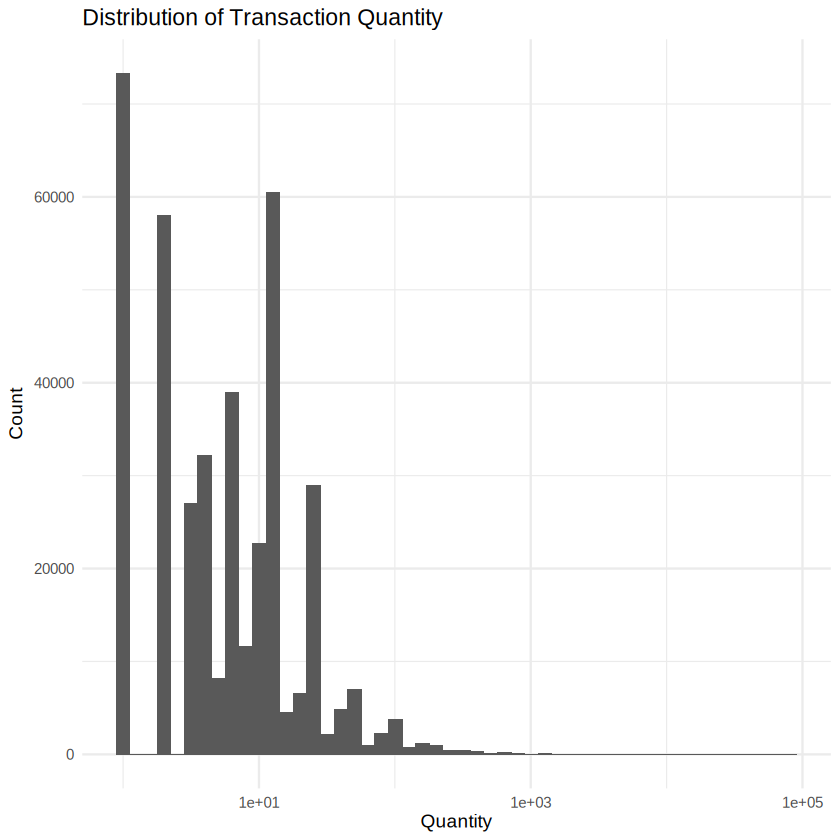

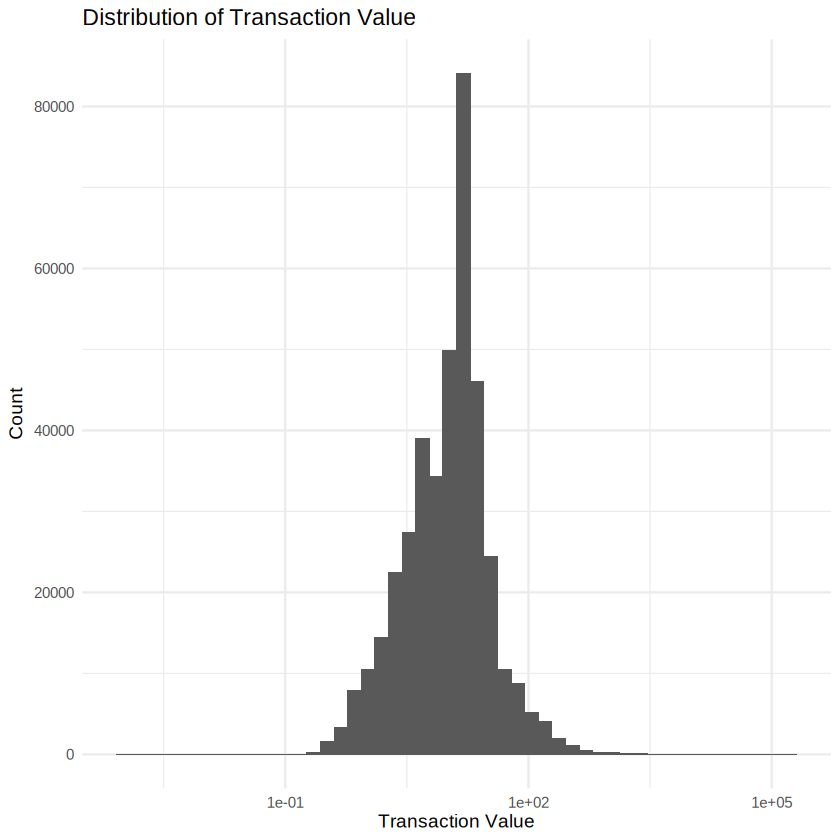

In [ ]:
ggplot(retail_clean, aes(x = Quantity)) +
  geom_histogram(bins = 50) +
  scale_x_log10() +
  labs(
    title = "Distribution of Transaction Quantity",
    x = "Quantity",
    y = "Count"
  ) +
  theme_minimal()

ggplot(retail_clean, aes(x = TotalPrice)) +
  geom_histogram(bins = 50) +
  scale_x_log10() +
  labs(
    title = "Distribution of Transaction Value",
    x = "Transaction Value",
    y = "Count"
  ) +
  theme_minimal()

## 6. Customer-Level Feature Engineering

RFM features are created for every customer:

- **Recency:** Days since the customer's latest purchase
- **Frequency:** Number of unique invoices
- **Monetary:** Total amount spent

Additional features:

- Average transaction value
- Total quantity purchased
- Purchase frequency

In [ ]:
reference_date <- max(retail_clean$InvoiceDate) + 1

customer_data <- retail_clean %>%
  group_by(CustomerID) %>%
  summarise(
    Recency = as.numeric(reference_date - max(InvoiceDate)),
    Frequency = n_distinct(InvoiceNo),
    Monetary = sum(TotalPrice),
    AvgTransactionValue = mean(TotalPrice),
    TotalQuantity = sum(Quantity),
    PurchaseFrequency = n_distinct(InvoiceNo) /
      as.numeric(max(InvoiceDate) - min(InvoiceDate) + 1),
    .groups = "drop"
  )

cat("Customer-level rows:", nrow(customer_data), "\n")
head(customer_data)

Customer-level rows: 4338 


CustomerID,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,PurchaseFrequency
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
12346,325.117373,1,77183.60,77183.60000,74215,1.00000000
12347,1.873623,7,4310.00,23.68132,2458,0.01912369
12348,74.984039,4,1797.24,57.97548,2341,0.01409678
12349,18.124317,1,1757.55,24.07603,631,1.00000000
12350,309.867373,1,334.40,19.67059,197,1.00000000
12352,35.925706,8,2506.04,29.48282,536,0.03064123


## 7. Outlier Treatment

Extreme customer values can strongly affect clustering.

The IQR method is used to cap extreme values.

In [ ]:
cap_outliers <- function(x) {
  q1 <- quantile(x, 0.25, na.rm = TRUE)
  q3 <- quantile(x, 0.75, na.rm = TRUE)
  iqr <- q3 - q1
  lower <- q1 - 1.5 * iqr
  upper <- q3 + 1.5 * iqr
  pmin(pmax(x, lower), upper)
}

feature_cols <- c(
  "Recency", "Frequency", "Monetary",
  "AvgTransactionValue", "TotalQuantity",
  "PurchaseFrequency"
)

customer_features <- customer_data

for (col in feature_cols) {
  customer_features[[col]] <- cap_outliers(customer_features[[col]])
}

summary(customer_features[, feature_cols])

    Recency         Frequency         Monetary       AvgTransactionValue
 Min.   :  1.00   Min.   : 1.000   Min.   :   3.75   Min.   : 2.101     
 1st Qu.: 18.13   1st Qu.: 1.000   1st Qu.: 307.42   1st Qu.:12.365     
 Median : 50.11   Median : 2.000   Median : 674.49   Median :17.723     
 Mean   : 91.32   Mean   : 3.487   Mean   :1162.91   Mean   :20.056     
 3rd Qu.:141.73   3rd Qu.: 5.000   3rd Qu.:1661.74   3rd Qu.:24.858     
 Max.   :327.14   Max.   :11.000   Max.   :3693.23   Max.   :43.598     
 TotalQuantity    PurchaseFrequency
 Min.   :   1.0   Min.   :0.00545  
 1st Qu.: 160.0   1st Qu.:0.02021  
 Median : 379.0   Median :0.04595  
 Mean   : 684.9   Mean   :0.37786  
 3rd Qu.: 992.8   3rd Qu.:1.00000  
 Max.   :2241.9   Max.   :2.46969  

## 8. Feature Scaling

The customer features have different units and ranges.

Standardization converts them to a comparable scale.

In [ ]:
scaled_features <- scale(customer_features[, feature_cols])

scaled_features <- as.data.frame(scaled_features)

rownames(scaled_features) <- customer_features$CustomerID

summary(scaled_features)

    Recency          Frequency          Monetary       AvgTransactionValue
 Min.   :-0.9324   Min.   :-0.8179   Min.   :-1.0097   Min.   :-1.5420    
 1st Qu.:-0.7556   1st Qu.:-0.8179   1st Qu.:-0.7452   1st Qu.:-0.6605    
 Median :-0.4254   Median :-0.4890   Median :-0.4254   Median :-0.2004    
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000    
 3rd Qu.: 0.5204   3rd Qu.: 0.4978   3rd Qu.: 0.4345   3rd Qu.: 0.4125    
 Max.   : 2.4345   Max.   : 2.4714   Max.   : 2.2040   Max.   : 2.0219    
 TotalQuantity     PurchaseFrequency
 Min.   :-0.9783   Min.   :-0.8060  
 1st Qu.:-0.7509   1st Qu.:-0.7740  
 Median :-0.4376   Median :-0.7183  
 Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.4404   3rd Qu.: 1.3464  
 Max.   : 2.2273   Max.   : 4.5271  

## 9. Elbow Method for K-Means

The Elbow Method compares the within-cluster sum of squares for different values of K.

The point where the reduction begins to slow down is used as a practical choice for K.

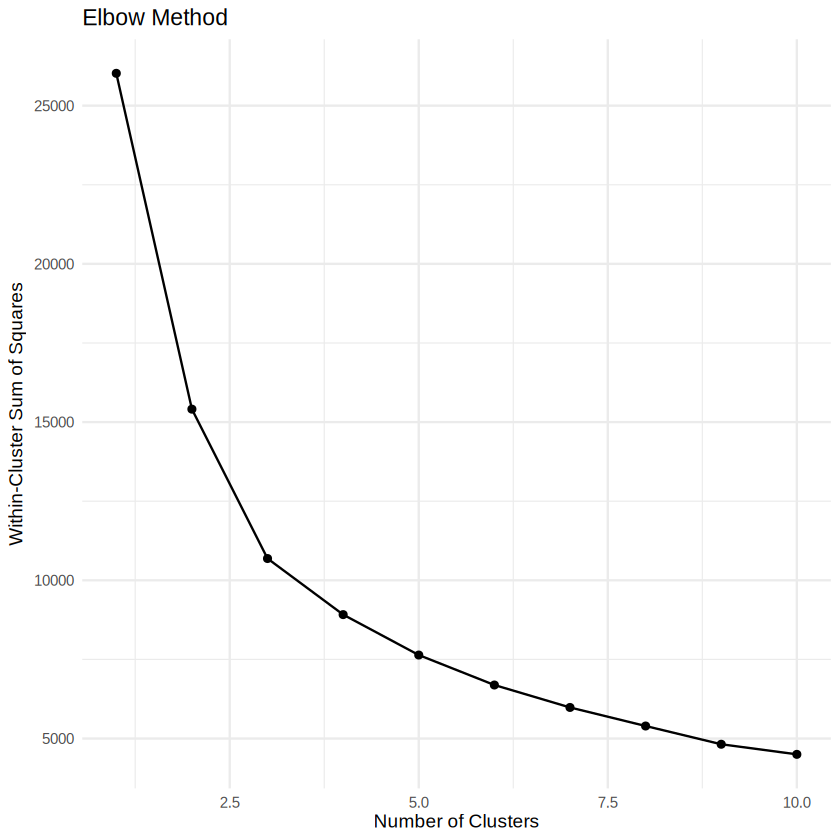

In [ ]:
wss <- numeric(10)

for (k in 1:10) {
  km <- kmeans(scaled_features, centers = k, nstart = 25)
  wss[k] <- km$tot.withinss
}

elbow_data <- data.frame(K = 1:10, WSS = wss)

ggplot(elbow_data, aes(x = K, y = WSS)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Elbow Method",
    x = "Number of Clusters",
    y = "Within-Cluster Sum of Squares"
  ) +
  theme_minimal()

## 10. K-Means Customer Segmentation

For this experiment, K = 4 is used as a practical segmentation choice.

The Silhouette Score is also used later to evaluate the clustering quality.

In [ ]:
k <- 4

kmeans_model <- kmeans(
  scaled_features,
  centers = k,
  nstart = 25
)

customer_features$KMeansCluster <- factor(kmeans_model$cluster)

cat("Cluster sizes:\n")
print(table(customer_features$KMeansCluster))

Cluster sizes:

   1    2    3    4 
1844  848  878  768 


## 11. Silhouette Score

The Silhouette Score measures how well each customer fits within its assigned cluster compared with other clusters.

Higher values generally indicate better-separated clusters.

Average K-Means Silhouette Score: 0.363 


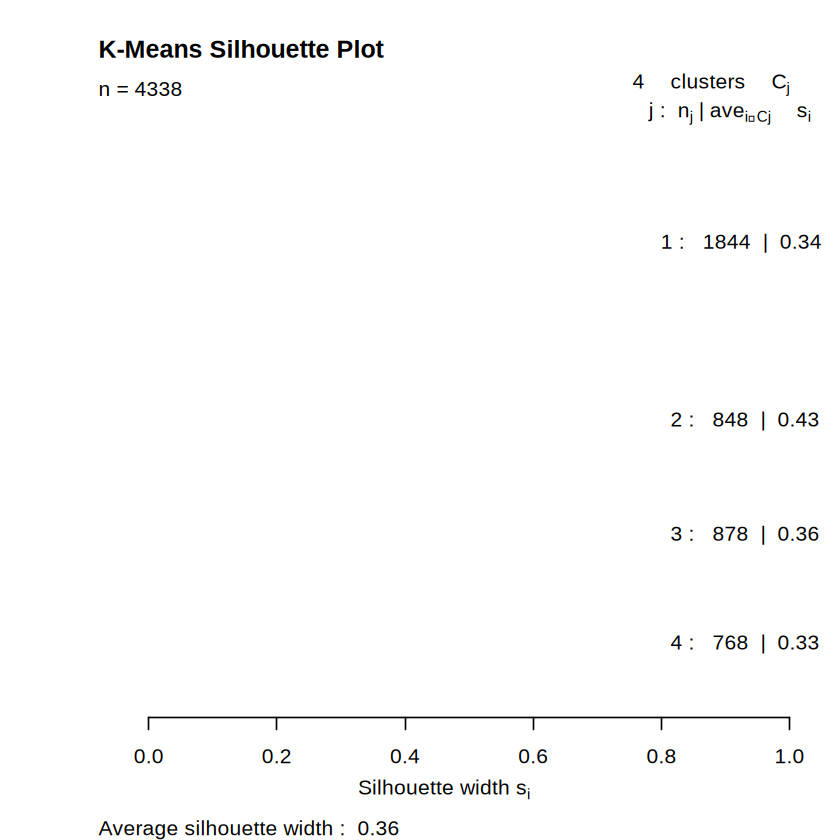

In [ ]:
library(cluster)
sil_kmeans <- silhouette(
  kmeans_model$cluster,
  dist(scaled_features)
)

avg_silhouette <- mean(sil_kmeans[, "sil_width"])

cat("Average K-Means Silhouette Score:", round(avg_silhouette, 4), "\n")

plot(
  sil_kmeans,
  main = "K-Means Silhouette Plot"
)

## 12. Hierarchical Clustering

Hierarchical clustering is performed using Euclidean distance and Ward's method.

A dendrogram is used to visualize the hierarchy of customer groups.

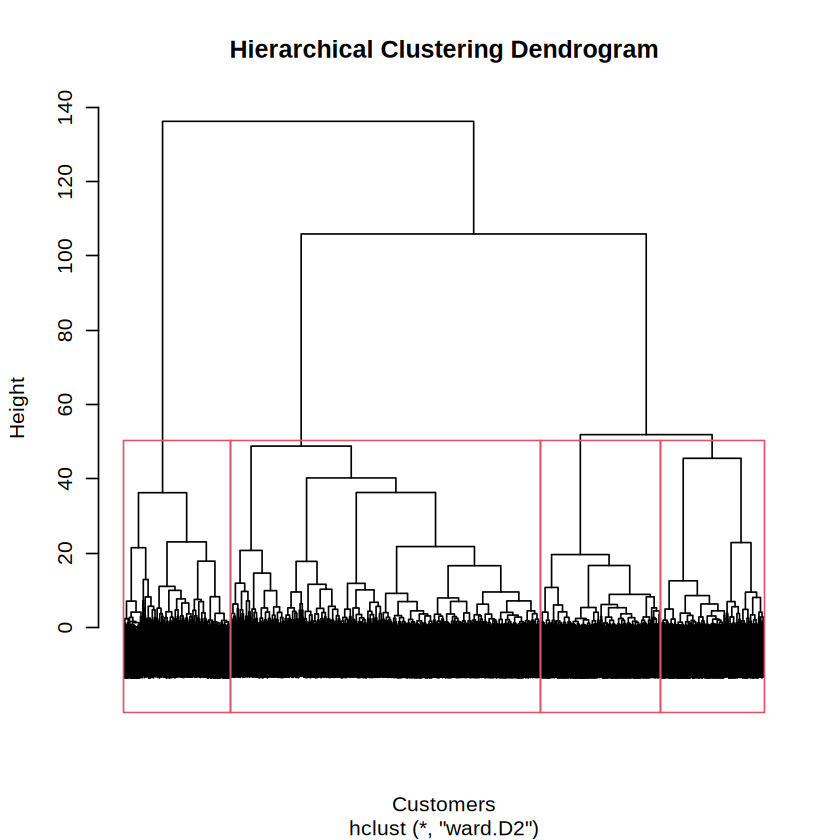

In [ ]:
distance_matrix <- dist(scaled_features)

hc_model <- hclust(
  distance_matrix,
  method = "ward.D2"
)

plot(
  hc_model,
  labels = FALSE,
  main = "Hierarchical Clustering Dendrogram",
  xlab = "Customers",
  ylab = "Height"
)

rect.hclust(
  hc_model,
  k = 4
)

## 13. Compare Hierarchical Clustering

The hierarchical clusters are cut into four groups and evaluated using the Silhouette Score.

Average Hierarchical Clustering Silhouette Score: 0.3213 


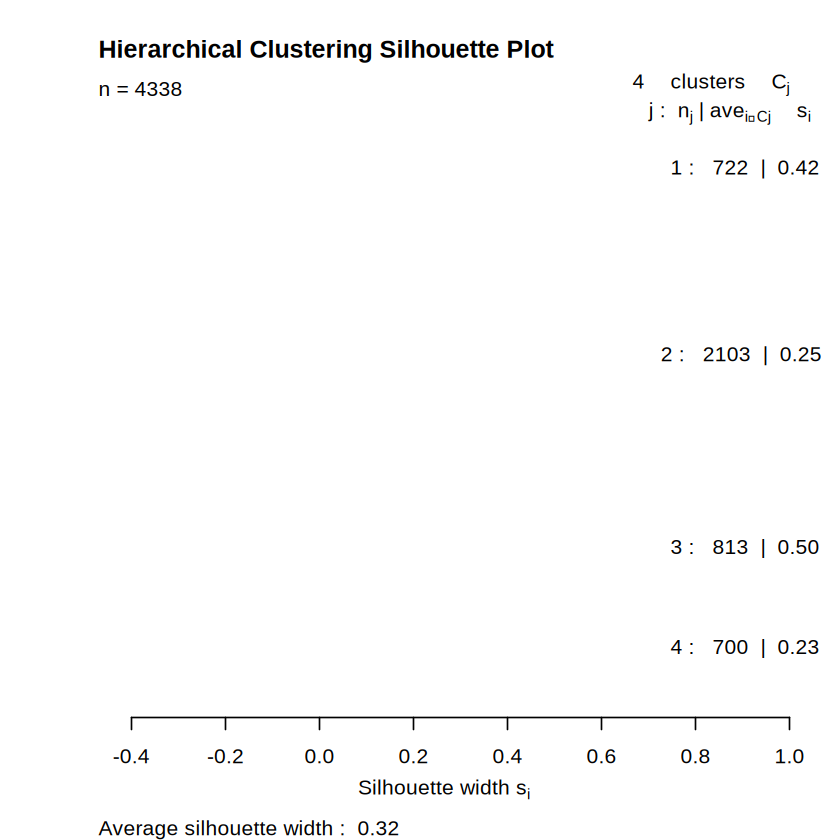

In [ ]:
hc_clusters <- cutree(hc_model, k = 4)

sil_hc <- silhouette(
  hc_clusters,
  distance_matrix
)

avg_silhouette_hc <- mean(sil_hc[, "sil_width"])

cat(
  "Average Hierarchical Clustering Silhouette Score:",
  round(avg_silhouette_hc, 4),
  "\n"
)

plot(
  sil_hc,
  main = "Hierarchical Clustering Silhouette Plot"
)

## 14. PCA for Dimensionality Reduction

PCA converts the customer features into principal components.

The first two components are used to visualize customer segments in two dimensions.

Variance explained by each component:
   PC1    PC2    PC3    PC4    PC5    PC6 
0.5690 0.1832 0.1161 0.0860 0.0357 0.0100 


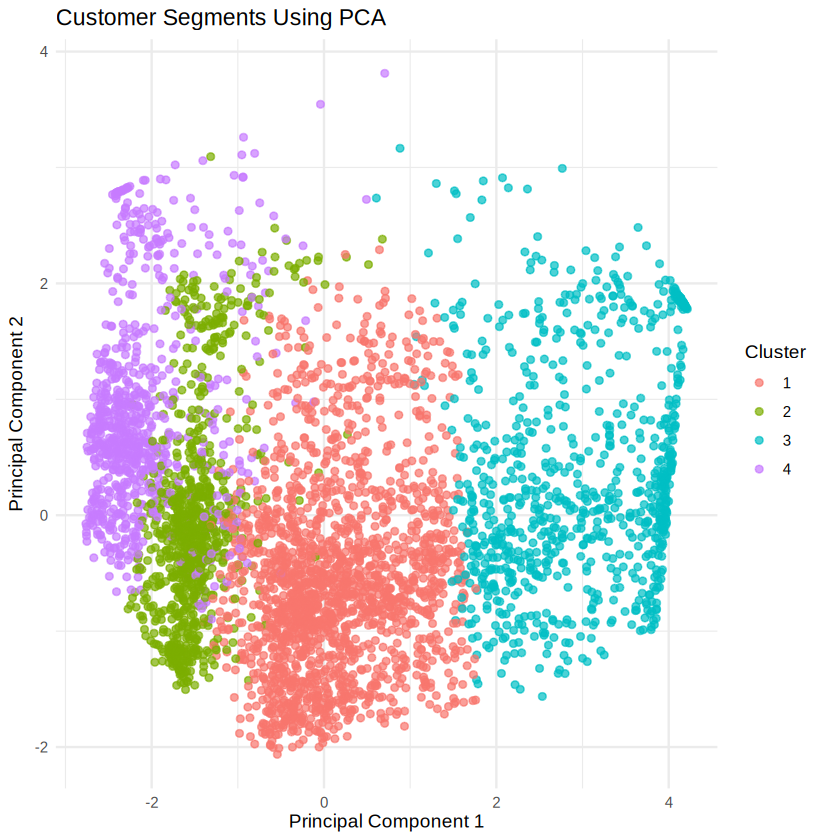

In [ ]:
pca_model <- prcomp(
  scaled_features,
  center = FALSE,
  scale. = FALSE
)

pca_variance <- summary(pca_model)$importance[2, ]

cat("Variance explained by each component:\n")
print(round(pca_variance, 4))

pca_data <- data.frame(
  PC1 = pca_model$x[, 1],
  PC2 = pca_model$x[, 2],
  Cluster = customer_features$KMeansCluster
)

ggplot(pca_data, aes(x = PC1, y = PC2, color = Cluster)) +
  geom_point(alpha = 0.7) +
  labs(
    title = "Customer Segments Using PCA",
    x = "Principal Component 1",
    y = "Principal Component 2"
  ) +
  theme_minimal()

## 15. Cluster Profiling

The average customer characteristics of every cluster are calculated to understand the segments.

In [ ]:
cluster_profile <- customer_features %>%
  group_by(KMeansCluster) %>%
  summarise(
    Customers = n(),
    Recency = mean(Recency),
    Frequency = mean(Frequency),
    Monetary = mean(Monetary),
    AvgTransactionValue = mean(AvgTransactionValue),
    TotalQuantity = mean(TotalQuantity),
    PurchaseFrequency = mean(PurchaseFrequency),
    .groups = "drop"
  )

print(cluster_profile)

# A tibble: 4 × 8
  KMeansCluster Customers Recency Frequency Monetary AvgTransactionValue
  <fct>             <int>   <dbl>     <dbl>    <dbl>               <dbl>
1 1                  1844    59.9      3.35     922.                18.3
2 2                   848    63.9      1.03     372.                18.8
3 3                   878    29.4      8.15    3145.                24.3
4 4                   768   268.       1.20     349.                20.7
# ℹ 2 more variables: TotalQuantity <dbl>, PurchaseFrequency <dbl>


## 16. Identify the High-Value Customer Segment

The cluster with the strongest combination of spending and purchasing activity is selected as the high-value segment.

This selection is based on the generated cluster profile.

In [ ]:
high_value_cluster <- cluster_profile$KMeansCluster[
  which.max(
    scale(cluster_profile$Monetary) +
    scale(cluster_profile$Frequency) +
    scale(cluster_profile$PurchaseFrequency)
  )
]

high_value_cluster <- as.character(high_value_cluster)

cat("Selected high-value cluster:", high_value_cluster, "\n")

customer_features$HighValue <- factor(
  ifelse(
    as.character(customer_features$KMeansCluster) == high_value_cluster,
    "Yes",
    "No"
  ),
  levels = c("No", "Yes")
)

table(customer_features$HighValue)

Selected high-value cluster: 3 



  No  Yes 
3460  878 

## 17. Prepare Data for Supervised Learning

The target variable is whether a customer belongs to the selected high-value segment.

The data is split into training and testing sets.

In [ ]:
model_data <- customer_features %>%
  select(all_of(feature_cols), HighValue) %>%
  drop_na()

set.seed(42)

train_index <- sample(
  seq_len(nrow(model_data)),
  size = floor(0.8 * nrow(model_data))
)

train_data <- model_data[train_index, ]
test_data <- model_data[-train_index, ]

cat("Training rows:", nrow(train_data), "\n")
cat("Testing rows:", nrow(test_data), "\n")

cat("\nTraining class distribution:\n")
print(table(train_data$HighValue))

Training rows: 3470 
Testing rows: 868 

Training class distribution:

  No  Yes 
2779  691 


## 18. Random Forest Model

Random Forest is trained to classify customers into high-value and non-high-value groups.

In [ ]:
rf_model <- randomForest(
  HighValue ~ .,
  data = train_data,
  ntree = 300,
  importance = TRUE
)

rf_pred <- predict(
  rf_model,
  test_data,
  type = "response"
)

rf_prob <- predict(
  rf_model,
  test_data,
  type = "prob"
)[, "Yes"]

cat("Random Forest model trained.\n")
print(rf_model)

Random Forest model trained.

Call:
 randomForest(formula = HighValue ~ ., data = train_data, ntree = 300,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 300
No. of variables tried at each split: 2

        OOB estimate of  error rate: 0.89%
Confusion matrix:
      No Yes class.error
No  2765  14 0.005037783
Yes   17 674 0.024602026


## 19. SVM Model

A Support Vector Machine classifier is trained using the same customer features.

In [ ]:
svm_model <- svm(
  HighValue ~ .,
  data = train_data,
  kernel = "radial",
  probability = TRUE
)

svm_pred <- predict(
  svm_model,
  test_data,
  probability = TRUE
)

svm_prob <- attr(
  svm_pred,
  "probabilities"
)[, "Yes"]

cat("SVM model trained.\n")

SVM model trained.


## 20. Confusion Matrices

Confusion matrices show the number of correct and incorrect predictions for each class.

In [ ]:
rf_cm <- table(
  Actual = test_data$HighValue,
  Predicted = rf_pred
)

svm_cm <- table(
  Actual = test_data$HighValue,
  Predicted = svm_pred
)

cat("Random Forest Confusion Matrix:\n")
print(rf_cm)

cat("\nSVM Confusion Matrix:\n")
print(svm_cm)

Random Forest Confusion Matrix:
      Predicted
Actual  No Yes
   No  676   5
   Yes   8 179

SVM Confusion Matrix:
      Predicted
Actual  No Yes
   No  680   1
   Yes   5 182


## 21. Classification Metrics

The models are compared using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [ ]:
calculate_metrics <- function(actual, predicted, probability) {
  actual_num <- ifelse(actual == "Yes", 1, 0)
  predicted_num <- ifelse(predicted == "Yes", 1, 0)

  tp <- sum(actual_num == 1 & predicted_num == 1)
  tn <- sum(actual_num == 0 & predicted_num == 0)
  fp <- sum(actual_num == 0 & predicted_num == 1)
  fn <- sum(actual_num == 1 & predicted_num == 0)

  accuracy <- (tp + tn) / (tp + tn + fp + fn)
  precision <- ifelse(tp + fp == 0, 0, tp / (tp + fp))
  recall <- ifelse(tp + fn == 0, 0, tp / (tp + fn))
  f1 <- ifelse(
    precision + recall == 0,
    0,
    2 * precision * recall / (precision + recall)
  )

  roc_obj <- roc(
    actual_num,
    probability,
    quiet = TRUE
  )

  auc_value <- as.numeric(auc(roc_obj))

  data.frame(
    Accuracy = accuracy,
    Precision = precision,
    Recall = recall,
    F1_Score = f1,
    ROC_AUC = auc_value
  )
}

rf_metrics <- calculate_metrics(
  test_data$HighValue,
  rf_pred,
  rf_prob
)

svm_metrics <- calculate_metrics(
  test_data$HighValue,
  svm_pred,
  svm_prob
)

model_comparison <- rbind(
  Random_Forest = rf_metrics,
  SVM = svm_metrics
)

print(round(model_comparison, 4))

              Accuracy Precision Recall F1_Score ROC_AUC
Random_Forest   0.9850    0.9728 0.9572   0.9650  0.9993
SVM             0.9931    0.9945 0.9733   0.9838  1.0000


## 22. ROC Curves

ROC curves compare the classification behaviour of Random Forest and SVM.

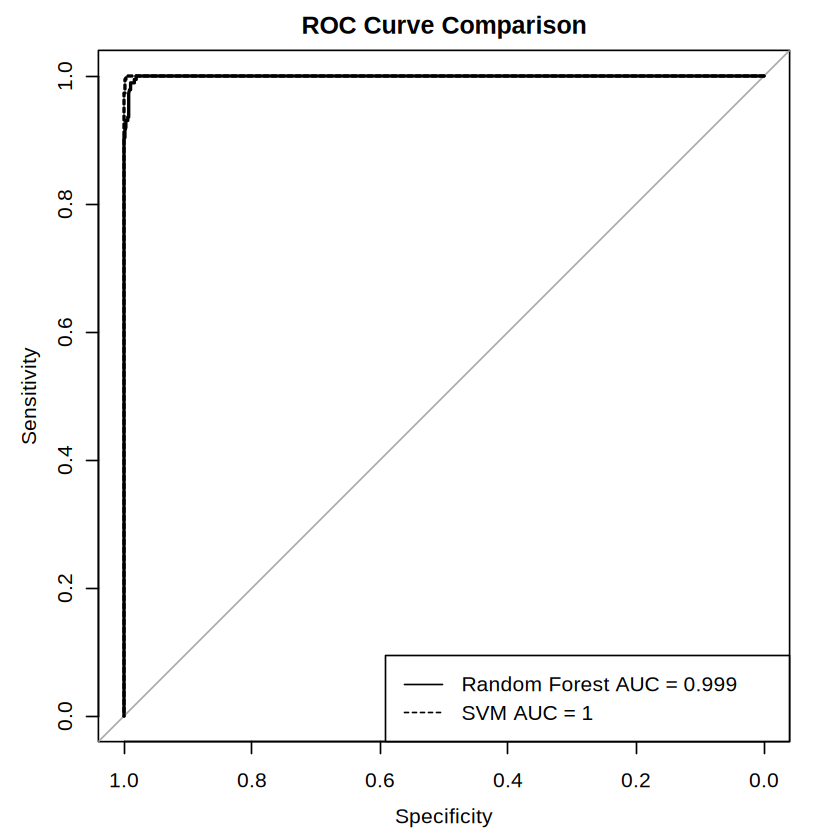

In [ ]:
rf_roc <- roc(
  ifelse(test_data$HighValue == "Yes", 1, 0),
  rf_prob,
  quiet = TRUE
)

svm_roc <- roc(
  ifelse(test_data$HighValue == "Yes", 1, 0),
  svm_prob,
  quiet = TRUE
)

plot(
  rf_roc,
  main = "ROC Curve Comparison"
)

lines(
  svm_roc,
  lty = 2
)

legend(
  "bottomright",
  legend = c(
    paste0("Random Forest AUC = ", round(auc(rf_roc), 3)),
    paste0("SVM AUC = ", round(auc(svm_roc), 3))
  ),
  lty = c(1, 2)
)

## 23. Random Forest Feature Importance

Feature importance shows which customer-level variables contribute most to the Random Forest predictions.

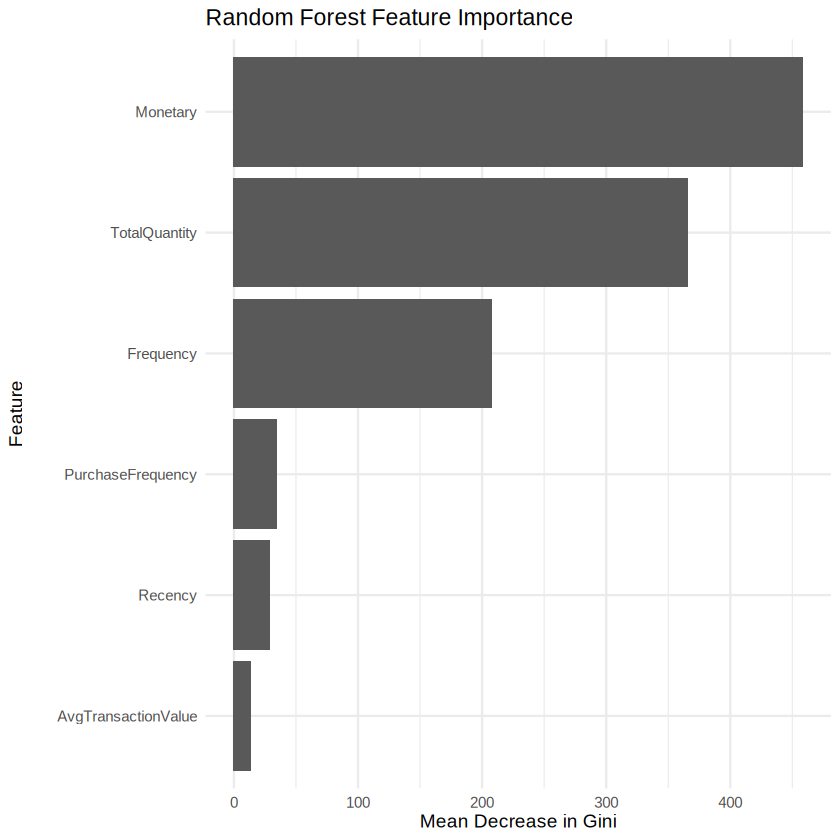

In [ ]:
importance_data <- as.data.frame(
  importance(rf_model)
)

importance_data$Feature <- rownames(importance_data)

importance_data <- importance_data %>%
  arrange(desc(MeanDecreaseGini))

ggplot(
  importance_data,
  aes(
    x = reorder(Feature, MeanDecreaseGini),
    y = MeanDecreaseGini
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Random Forest Feature Importance",
    x = "Feature",
    y = "Mean Decrease in Gini"
  ) +
  theme_minimal()

## 24. Interactive 3D Customer Cluster Visualization

Plotly is used to create an interactive 3D visualization using the first three principal components.

In [ ]:
pca_3d <- data.frame(
  PC1 = pca_model$x[, 1],
  PC2 = pca_model$x[, 2],
  PC3 = pca_model$x[, 3],
  Cluster = customer_features$KMeansCluster,
  CustomerID = customer_features$CustomerID
)

plot_ly(
  pca_3d,
  x = ~PC1,
  y = ~PC2,
  z = ~PC3,
  color = ~Cluster,
  text = ~CustomerID,
  type = "scatter3d",
  mode = "markers",
  marker = list(size = 4)
) %>%
  layout(
    title = "Interactive 3D Customer Segments"
  )

HTML widgets cannot be represented in plain text (need html)

## 25. Cluster-Wise Visualization

The customer count in each K-Means segment is visualized.

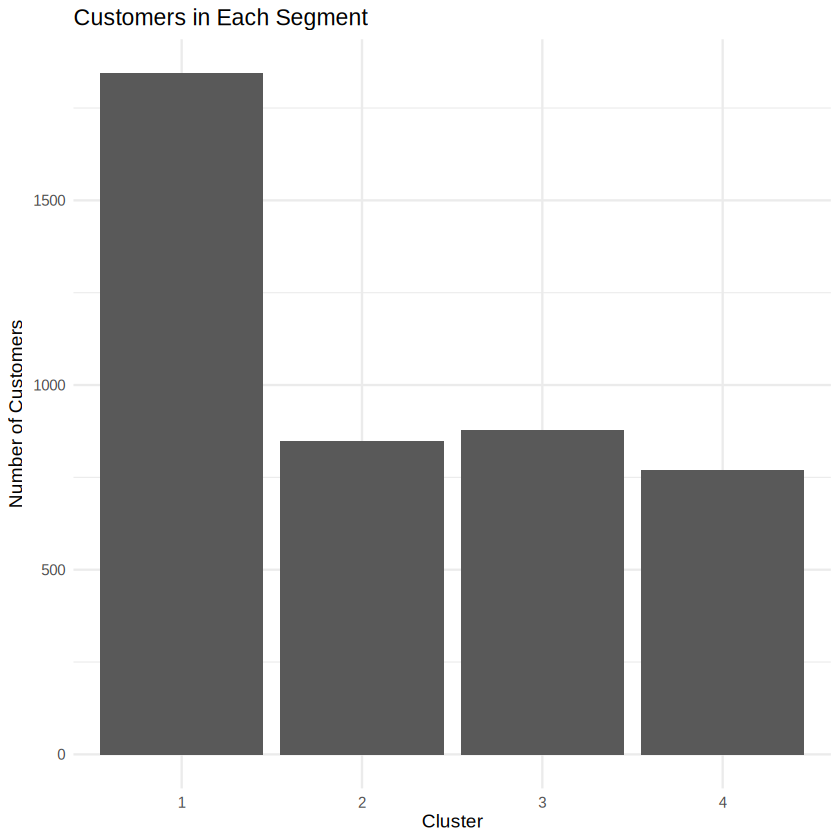

In [ ]:
cluster_counts <- customer_features %>%
  count(KMeansCluster)

ggplot(
  cluster_counts,
  aes(x = KMeansCluster, y = n)
) +
  geom_col() +
  labs(
    title = "Customers in Each Segment",
    x = "Cluster",
    y = "Number of Customers"
  ) +
  theme_minimal()

## 26. Segment-Wise Marketing Recommendations

The recommendations below are based on the purchasing characteristics observed in each cluster.

- High-value customers: loyalty rewards, exclusive offers, and retention campaigns
- Frequent customers: personalized offers and repeat-purchase incentives
- Low-frequency customers: re-engagement campaigns and product recommendations
- Low-spending customers: introductory offers and cross-selling campaigns

The exact strategy should be adjusted using the generated cluster profiles.

In [ ]:
marketing_summary <- cluster_profile %>%
  mutate(
    Recommendation = case_when(
      as.character(KMeansCluster) == high_value_cluster ~
        "Loyalty rewards, exclusive offers, and retention campaigns",
      Frequency >= median(Frequency) & Monetary >= median(Monetary) ~
        "Personalized offers and repeat-purchase incentives",
      Frequency < median(Frequency) & Monetary < median(Monetary) ~
        "Re-engagement campaigns and product recommendations",
      TRUE ~
        "Introductory offers and cross-selling campaigns"
    )
  )

print(marketing_summary)

# A tibble: 4 × 9
  KMeansCluster Customers Recency Frequency Monetary AvgTransactionValue
  <fct>             <int>   <dbl>     <dbl>    <dbl>               <dbl>
1 1                  1844    59.9      3.35     922.                18.3
2 2                   848    63.9      1.03     372.                18.8
3 3                   878    29.4      8.15    3145.                24.3
4 4                   768   268.       1.20     349.                20.7
# ℹ 3 more variables: TotalQuantity <dbl>, PurchaseFrequency <dbl>,
#   Recommendation <chr>


## 27. Final Results Summary


In [ ]:
cat("==============================================\n")
cat("FINAL EXPERIMENT SUMMARY\n")
cat("==============================================\n")

cat("\nNumber of customers:", nrow(customer_features), "\n")
cat("Number of K-Means clusters:", k, "\n")
cat(
  "K-Means Silhouette Score:",
  round(avg_silhouette, 4),
  "\n"
)
cat(
  "Hierarchical Silhouette Score:",
  round(avg_silhouette_hc, 4),
  "\n"
)
cat(
  "Selected high-value cluster:",
  high_value_cluster,
  "\n"
)

cat("\nModel Comparison:\n")
print(round(model_comparison, 4))

FINAL EXPERIMENT SUMMARY

Number of customers: 4338 
Number of K-Means clusters: 4 
K-Means Silhouette Score: 0.363 
Hierarchical Silhouette Score: 0.3213 
Selected high-value cluster: 3 

Model Comparison:
              Accuracy Precision Recall F1_Score ROC_AUC
Random_Forest   0.9850    0.9728 0.9572   0.9650  0.9993
SVM             0.9931    0.9945 0.9733   0.9838  1.0000


# Conclusion

The experiment performs an end-to-end customer analytics workflow using the UCI Online Retail dataset.

Customer transaction data is cleaned and transformed into customer-level RFM and purchasing features. K-Means and Hierarchical Clustering are used to identify customer segments, while Silhouette Scores are used to evaluate clustering quality.

PCA provides a lower-dimensional view of the customer segments, and Plotly provides an interactive 3D visualization.

A high-value customer segment is identified from the cluster profiles. Random Forest and SVM are then trained to predict whether a customer belongs to this segment. Their performance is compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.

The resulting customer profiles can support targeted marketing strategies for different customer segments.